# Проект: Исследование стартапов

## Введение

# Анализ рынка стартапов и инвестиционной активности

## Введение

В рамках проекта был проведён анализ данных о стартапах, инвестициях и сделках с компаниями. Основная задача — понять, какие факторы могут влиять на привлечение инвестиций и итоговую стоимость компаний при продаже.

Проект ориентирован на практическое применение: результаты могут использоваться для оценки инвестиционной привлекательности стартапов и анализа рисков.

## Цель исследования

- подготовить и очистить данные о стартапах  
- проанализировать инвестиционную активность  
- выявить закономерности в сделках и финансировании  
- определить факторы, связанные со стоимостью компаний  

## Данные

В работе использованы следующие датасеты:

- `company_and_rounds` — информация о компаниях и раундах инвестиций  
- `acquisition` — данные о сделках по покупке компаний  
- `people` — информация об участниках компаний  
- `education` и `degrees` — данные об образовании  

Данные объединяются между собой по ключевым идентификаторам, что позволяет проводить комплексный анализ.

---

## Подготовка данных

На первом этапе были загружены все датасеты и проведена первичная проверка:

- проверены названия столбцов  
- изучена структура таблиц и типы данных  
- выявлены пропуски и возможные аномалии  

Эти шаги необходимы для того, чтобы корректно провести дальнейший анализ и избежать ошибок в интерпретации результатов.

## Первичный обзор данных

На этом этапе загрузил все основные датасеты, которые используются в проекте:

- acquisition  
- company_and_rounds  
- people  
- education  
- degrees  

Далее посмотрел структуру таблиц: названия столбцов, типы данных и общее содержание.

Основная задача на этом шаге, понять с какими данными предстоит работать и есть ли очевидные проблемы, которые нужно исправить перед анализом.

В процессе проверки:
- привёл названия столбцов к более удобному формату  
- посмотрел типы данных и при необходимости скорректировал  
- обратил внимание на пропуски и странные значения  

Этот шаг нужен, чтобы дальше не собирать ошибки и не искажать результаты анализа.

In [24]:
# подгрузим библиотеки заранее
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [25]:
company_rounds = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
acquisition = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
people = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')
education = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
degrees = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')


In [26]:
#посмотрим основные таблмцы

print('company_and_rounds')
display(company_rounds.head())
company_rounds.info()

print('\nacquisition')
display(acquisition.head())
acquisition.info()

print('\npeople')
display(people.head())
people.info()

print('\neducation')
display(education.head())
education.info()

print('\ndegrees')
display(degrees.head())
degrees.info()

company_and_rounds


,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217471 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB

people


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226700 non-null  object 
 2   last_name         226705 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB

education


,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB

degrees


,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98389 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


In [27]:
#Преобразуем названия столбцов к удобному формату

company_rounds.columns = [
    'company_id', 'name', 'category_code', 'status', 'founded_at', 'closed_at',
    'domain', 'network_username', 'country_code', 'investment_rounds', 'funding_rounds',
    'funding_total', 'milestones', 'funding_round_id', 'company_round_id', 'funded_at',
    'funding_round_type', 'raised_amount', 'pre_money_valuation', 'participants',
    'is_first_round', 'is_last_round'
]

acquisition.columns = [
    'id', 'acquiring_company_id', 'acquired_company_id', 'term_code', 'price_amount', 'acquired_at'
]

people.columns = [
    'id', 'first_name', 'last_name', 'company_id', 'network_username'
]

education.columns = [
    'id', 'person_id', 'institution', 'graduated_at'
]

degrees.columns = [
    'id', 'person_id', 'degree_type', 'subject'
]
#объединяю id компании, если основной id отсутствует, то беру из данных по раундам
company_rounds['company_id'] = company_rounds['company_id'].fillna(company_rounds['company_round_id'])

    В таблицах много пропусков в датах, категориях и network_username.
    Предположительно, это связано с объединением данных из разных источников (информация о компаниях и раундах инвестирования).
    
    Чтобы не терять данные, пропуски в `company_id` были заполнены значениями из `company_round_id`.
	
    Названия столбцов с пробелами неудобны, их стоит исправить на snake case.
    
	Даты нужно перевести в формат datetime, идентификаторы привести к единому виду для объединения.

### Обработка дат и оценка данных

Привёл столбцы с датами к формату datetime. Для этого ориентировался на названия колонок с суффиксом `_at`, чтобы не прописывать каждый столбец вручную.

Такой подход позволяет быстрее обрабатывать данные и не дублировать код.

После преобразования дат посмотрел на полноту данных. В таблицах есть пропуски, особенно в полях с датами и дополнительной информацией, но они не критичны для дальнейшего анализа.

В целом данных достаточно для решения задач: есть информация о компаниях, инвестициях и сделках, что позволяет проводить дальнейшее исследование.

In [28]:
# привожу все столбцы с датами к datetime (ориентируюсь на суффикс _at)
tables = [company_rounds, acquisition, education]

for df in tables:
    for col in df.columns:
        if col.endswith('_at'):
            df[col] = pd.to_datetime(df[col], errors='coerce')

In [29]:

print('company_and_rounds')
display(company_rounds[['category_code','founded_at','closed_at','network_username']].notna().mean())

print('\nacquisition')
display(acquisition[['term_code','price_amount','acquired_at']].notna().mean())

print('\npeople')
display(people[['company_id','network_username']].notna().mean())

print('\neducation')
display(education[['institution','graduated_at']].notna().mean())

print('\ndegrees')
display(degrees[['degree_type','subject']].notna().mean())

company_and_rounds


category_code       0.660712
founded_at          0.504909
closed_at           0.015838
network_username    0.438684
dtype: float64


acquisition


term_code       0.194642
price_amount    1.000000
acquired_at     0.996917
dtype: float64


people


company_id          0.152685
network_username    0.171440
dtype: float64


education


institution     0.999498
graduated_at    0.529641
dtype: float64


degrees


degree_type    0.897628
subject        0.741702
dtype: float64


По результатам проверки видно, что качество данных сильно различается по таблицам.

--В `company_and_rounds` основные показатели по инвестициям заполнены, но дополнительные поля вроде категории (66%) и даты основания (50%) имеют заметные пропуски. Дата закрытия почти всегда отсутствует, что ожидаемо, так как большинство компаний продолжают работать.

--В `acquisition` данные выглядят наиболее полными: цена сделки заполнена полностью, дата сделки почти всегда указана. При этом тип сделки (`term_code`) заполнен только примерно в 20% случаев.

--В `people` данные достаточно разреженные: только около 15% записей связаны с компаниями, что ограничивает возможность анализа связей между людьми и бизнесом.

-- В `education` информация об учебных заведениях почти полностью заполнена, но даты окончания есть только примерно в половине случаев.

--  `degrees` данные выглядят достаточно полными, особенно по типу образования.

В целом данные не идеальные, но для анализа инвестиций и сделок они подходят: ключевые показатели (суммы инвестиций, сделки) заполнены хорошо, а пропуски в дополнительных полях не критичны для основной задачи.

Данных в целом достаточно для анализа стартапов, их категорий, финансирования и частично сотрудников. Для некоторых столбцов с большим числом пропусков (closed at, network_username, graduated_at) нужно учитывать, что выводы будут неполными.

In [30]:
print("people:", people.duplicated().sum())
print("education:", education.duplicated().sum())
print("degrees:", degrees.duplicated().sum())
print("company_rounds:", company_rounds.duplicated().sum())
print("acquisition:", acquisition.duplicated().sum())

people: 0
education: 0
degrees: 0
company_rounds: 0
acquisition: 0


Дубликаты не обнаружены

## Анализ инвестиционной активности по годам

Для начала посмотрел, как менялись инвестиции со временем. Взял данные по раундам финансирования и сгруппировал их по годам.

Для каждого года посчитал:
- типичный размер раунда
- общее количество раундов

Чтобы убрать редкие и нерепрезентативные значения, оставил только те годы, где было больше 50 раундов.

Далее построил график, чтобы посмотреть динамику инвестиций и понять, как менялся рынок со временем.

Отдельно обратил внимание на:
- год с максимальным типичным размером инвестиций  
- поведение рынка в 2013 году (как менялись количество раундов и их размер)

In [8]:
company_rounds['funded_year'] = company_rounds['funded_at'].dt.year

pivot = company_rounds.pivot_table(
    index='funded_year',
    values='raised_amount',
    aggfunc=['median', 'count']
)

pivot.columns = ['typical_amount', 'rounds_count']
pivot = pivot.reset_index()
pivot = pivot[pivot['rounds_count'] > 50]

pivot

,funded_year,typical_amount,rounds_count
15,1999.0,2000000.0,76
16,2000.0,4200000.0,125
17,2001.0,3000000.0,96
18,2002.0,4200000.0,116
19,2003.0,3000000.0,159
20,2004.0,5000000.0,291
21,2005.0,5500000.0,1633
22,2006.0,5000000.0,2436
23,2007.0,3973320.0,3279
24,2008.0,3110000.0,3774


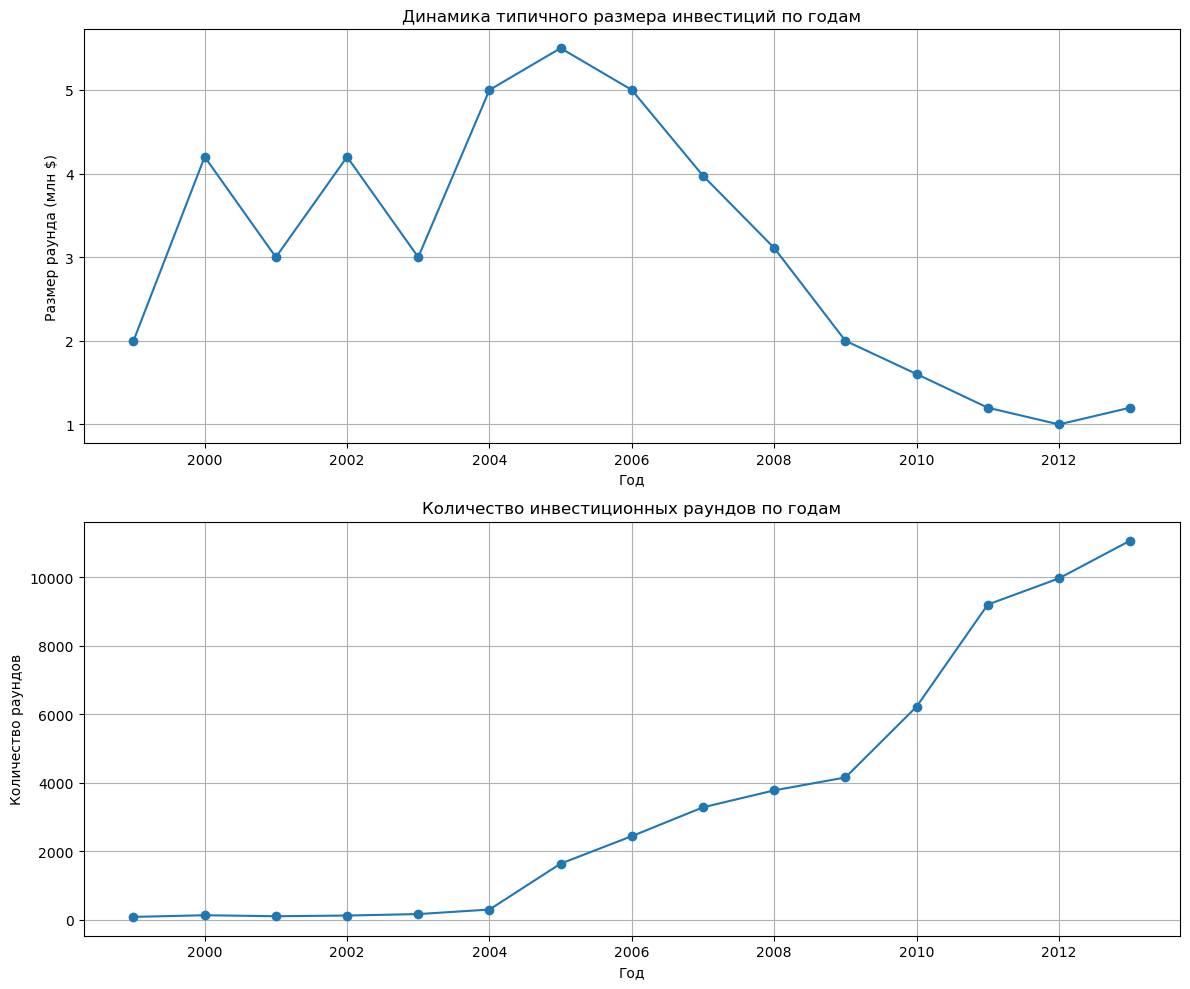

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# график среднего размера раунда (в млн $)
axes[0].plot(pivot['funded_year'], pivot['typical_amount'] / 1e6, marker='o')
axes[0].set_title('Динамика типичного размера инвестиций по годам')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Размер раунда (млн $)')
axes[0].grid(True)

# график количества раундов
axes[1].plot(pivot['funded_year'], pivot['rounds_count'], marker='o')
axes[1].set_title('Количество инвестиционных раундов по годам')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Количество раундов')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Максимальный типичный размер раунда был в 2005 году - 5 500 000 долларов.

В 2013 году количество раундов достигло 11 072, а типичный размер средств составил 1 200 000 долларов, что показывает снижение суммы на раунд при росте числа раундов.

В районе 2004 года наблюдаеися начало роста количества раундов и подход к пику динамики размера инвестиций

## Анализ данных о сотрудниках и их образовании

Отдельно посмотрел, насколько полно представлены данные об образовании сотрудников и зависит ли это от размера компании.

Для этого объединил данные из таблиц `people` и `education`, после чего сгруппировал компании по количеству сотрудников.

Далее для каждой группы оценил долю сотрудников, по которым отсутствует информация об образовании. Это позволяет понять, в каких компаниях данные заполнены хуже.

Границы групп выбрал исходя из распределения компаний по числу сотрудников, чтобы в каждой группе было достаточно наблюдений и можно было делать выводы.

Также отдельно проверил, можно ли использовать таблицу `degrees` для расширения анализа. Это важно, так как она может дополнить информацию об образовании и повысить полноту данных.

In [10]:
# Считаем количество сотрудников на компанию
staff_counts = people.groupby("company_id")["id"].count().reset_index(name="staff_total")

print(staff_counts["staff_total"].describe())

print(staff_counts["staff_total"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]))

count    22922.000000
mean         1.510121
std          2.764321
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        244.000000
Name: staff_total, dtype: float64
0.00      1.0
0.25      1.0
0.50      1.0
0.75      1.0
0.90      2.0
0.95      4.0
0.99      8.0
1.00    244.0
Name: staff_total, dtype: float64


Логично разделить компании на группы примерно так:
	1.	1 сотрудник — микро-компании.
	2.	2–4 сотрудника — маленькие компании.
	3.	5–8 сотрудников — средние компании.
	4.	9+ сотрудников — крупные компании.

In [11]:

merged = people.merge(education, left_on="id", right_on="person_id", how="left")

merged["has_edu"] = merged["institution"].notna().astype(int)

merged_staff = merged.groupby("company_id").agg(
    staff_total=("company_id", "count"),  # считаем количество сотрудников
    staff_with_edu=("has_edu", "sum")
).reset_index()

merged_staff["staff_without_edu_share"] = 1 - merged_staff["staff_with_edu"] / merged_staff["staff_total"]
bins = [0, 1, 4, 8, 50, float("inf")]
labels = ["1", "2-4", "5-8", "9-50", "51+"]
merged_staff["company_group"] = pd.cut(merged_staff["staff_total"], bins=bins, labels=labels, right=True)

result = merged_staff.groupby("company_group")["staff_without_edu_share"].mean().reset_index()
print(result)

  company_group  staff_without_edu_share
0             1                 0.592862
1           2-4                 0.232083
2           5-8                 0.297373
3          9-50                 0.320004
4           51+                 0.183592


C:\Users\Радмир\AppData\Local\Temp\ipykernel_13428\170428141.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = merged_staff.groupby("company_group")["staff_without_edu_share"].mean().reset_index()


Средняя доля сотрудников без информации об образовании сильно зависит от размера компании: в самых маленьких компаниях (1 сотрудник) почти 60 % сотрудников без данных об образовании, а в крупных компаниях (51+) эта доля снижается до 18 %.

Границы групп выбраны по квантилям и логике естественного разрыва числа сотрудников: 1, 2-4, 5–8, 9–50, 51+.

Присоединение degrees возможно, но оно не сильно увеличит полноту информации о сотрудниках и усложнит анализ, поэтому для текущей задачи по оценке доли сотрудников без информации об образовании его можно не использовать.

## Проверка ключей для объединения таблиц

После первичного анализа стало понятно, что основной ключ для объединения — это `company_id`.  

Дополнительно решил проверить столбец `network_username`, так как он встречается сразу в нескольких таблицах и потенциально тоже может использоваться для объединения.

Проверил, насколько часто значения в этом столбце совпадают между таблицами и нет ли дублирования или расхождений.

Это важно, так как использование некорректного ключа может привести к потере данных или ошибкам при объединении.

В результате оценил, можно ли использовать `network_username` как альтернативный ключ или лучше ограничиться `company_id`.

In [12]:
people['network_username'].agg(['count', 'nunique'])


count      38867
nunique    38421
Name: network_username, dtype: int64

In [13]:

company_rounds['network_username'].agg(['count', 'nunique'])

count      95534
nunique    79571
Name: network_username, dtype: int64

в company_and_rounds у нас 95 534 непустых значений и 79 571 уникальное, значит дубликаты встречаются заметнее около 16 % случаев.

Следующий логичный шаг оценить пересечение ников между people и company_and_rounds, чтобы понять, насколько совпадения достаточно для объединения.

In [14]:
common_usernames = set(people['network_username'].dropna()) & set(company_rounds['network_username'].dropna())
len(common_usernames)

2199

Из 38 867 уникальных ников в people и 79 571 в company_and_rounds всего 2 199 пересекаются.

Это очень мало ~6%, поэтому столбец network_username не подходит для объединения данных слишком мало совпадений, чтобы соединение было полезным.

## Проблемный датасет и работа с пропусками

В процессе анализа стало понятно, что таблица `company_and_rounds` устроена не совсем удобно для работы.

В ней одновременно содержатся данные и о компаниях, и о раундах финансирования. Из-за этого одна компания может встречаться в нескольких строках, а часть полей при этом остаётся пустой. Например, в строках с информацией о компании нет данных по раундам, и наоборот.

Скорее всего, изначально данные хранились раздельно (компании и раунды), а затем были объединены в одну таблицу. Это и объясняет большое количество пропусков.

Чтобы корректно работать с данными, привёл их к более удобному виду:
- отделил логику работы с компаниями и раундами  
- сохранил связь между ними через `company_id`  
- постарался минимизировать потерю данных  

Такой подход позволяет дальше анализировать компании без искажения показателей и без необходимости каждый раз дополнительно агрегировать данные.

Названия столбцов мы переименовали ранее для удобной работы

In [15]:
numeric_cols = ['investment_rounds', 'funding_rounds', 'funding_total',
                'milestones', 'raised_amount', 'pre_money_valuation', 'participants',
                'is_first_round', 'is_last_round']

for col in numeric_cols:
    company_rounds[col] = pd.to_numeric(company_rounds[col], errors='coerce')

In [16]:
company_summary = company_rounds.groupby('company_id').agg(
    total_rounds=('funding_rounds', 'max'),
    total_raised=('raised_amount', 'sum'),
    first_funding=('funded_at', 'min'),
    last_funding=('funded_at', 'max')
).reset_index()

	1.	Привели даты к типу datetime еще ранее
	2.	Привели числовые колонки к числовому типу.
	3.	Сохранили все детали, чтобы можно было фильтровать по любым параметрам.
	4.	Создали агрегированную таблицу company_summary для удобного расчёта показателей на компанию, не теряя связности исходных данных.
    5. Преобразовали названия стобцов также ранее в первой части.

In [17]:
company_summary

,company_id,total_rounds,total_raised,first_funding,last_funding
0,1.0,3.0,3.975000e+07,2005-10-01,2008-05-19
1,2.0,0.0,0.000000e+00,NaT,NaT
2,3.0,0.0,0.000000e+00,NaT,NaT
3,4.0,4.0,4.500000e+07,2005-10-01,2011-07-12
4,5.0,11.0,2.425700e+09,2004-09-01,2011-01-21
...,...,...,...,...,...
196780,286210.0,0.0,0.000000e+00,NaT,NaT
196781,286211.0,0.0,0.000000e+00,NaT,NaT
196782,286212.0,0.0,0.000000e+00,NaT,NaT
196783,286213.0,0.0,0.000000e+00,NaT,NaT


## Формирование выборки для анализа

На следующем этапе собрал объединённую таблицую.

В качестве базы использовал данные из `company_and_rounds`, но предварительно отфильтровал компании. Оставив только те, которые потенциально интересны с точки зрения сделок:

- компании с инвестициями (`funding_rounds > 0` или `investment_rounds > 0`)  
- компании со статусом `acquired`  

Если в компанию уже инвестировали или она была приобретена, значит она участвует в рынке сделок и имеет смысл для анализа.

После этого дополнительно проверил данные:
- нет ли явных дубликатов  
- корректно ли заполнены ключевые поля  
- не потерялись ли важные значения после фильтрации  
Дальнейший анализ выполняется уже на этой выборке.

In [18]:
researched_companies = company_rounds[
    (company_rounds['funding_rounds'] > 0) |
    (company_rounds['investment_rounds'] > 0) |
    (company_rounds['status'] == 'acquired')
].copy()

researched_companies = researched_companies.drop_duplicates(subset='company_id')

print(researched_companies.shape[0])

key_columns = ['category_code', 'founded_at', 'closed_at', 'network_username', 'country_code', 'funding_total']
print(researched_companies[key_columns].notna().mean())
researched_companies.head()

40747
category_code       0.866690
founded_at          0.682431
closed_at           0.052225
network_username    0.511694
country_code        0.852627
funding_total       1.000000
dtype: float64


,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_round_id,company_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,funded_year
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0,2005.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,...,1644.0,1001.0,2008-02-26,series-a,5000000.0,0.0,3.0,1.0,1.0,2008.0
20,10014.0,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0.0,...,6682.0,10014.0,2008-09-01,angel,0.0,0.0,1.0,1.0,1.0,2008.0


Получилось порядка 40000 компаний, что хватит для полноты картины.


### Анализ выбросов

Изучу размер средств, который предоставлялся компаниям.
- По предобработанному столбцу `funding_total` графическим способом оценил какой размер общего финансирования для одной компании будет типичным, а какой  выбивающимся. Было изучено распределение финансирования


count    2.787400e+04
mean     1.481652e+07
std      6.775936e+07
min      2.910000e+02
25%      5.000000e+05
50%      2.564500e+06
75%      1.100000e+07
max      5.700000e+09
Name: funding_total, dtype: float64


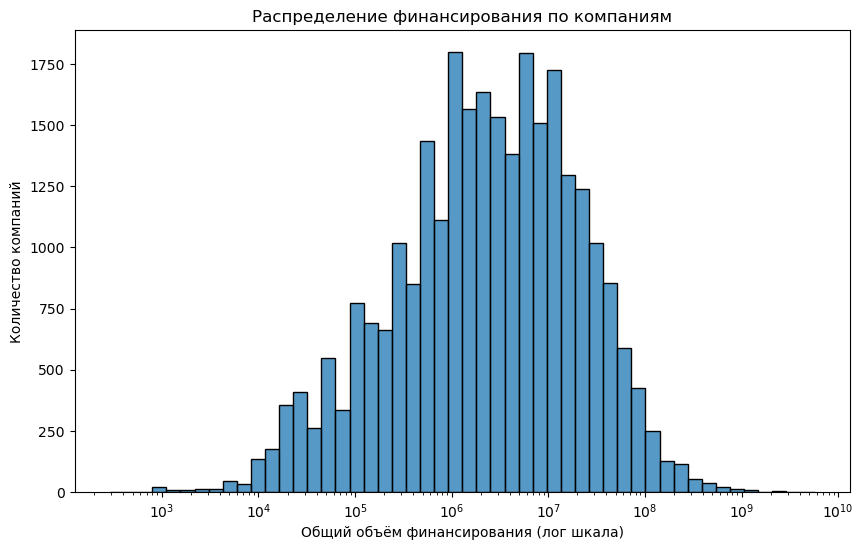

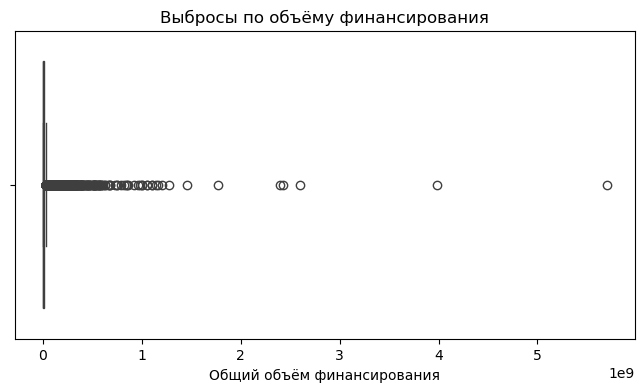

In [31]:
#без нулей и пропусков
funding_clean = researched_companies['funding_total']
funding_clean = funding_clean[funding_clean > 0].dropna()

print(funding_clean.describe())

plt.figure(figsize=(10,6))
sns.histplot(funding_clean, bins=50, log_scale=(True, False))
plt.xlabel('Общий объём финансирования (лог шкала)')
plt.ylabel('Количество компаний')
plt.title('Распределение финансирования по компаниям')
plt.show()

#боксплот
plt.figure(figsize=(8,4))
sns.boxplot(x=funding_clean)
plt.xlabel('Общий объём финансирования')
plt.title('Выбросы по объёму финансирования')
plt.show()

По данным видно, что распределение суммы финансирования сильно скошено вправо: большинство компаний получают относительно небольшие суммы, медиана составляет около 2,56 млн, а верхние выбросы достигают нескольких миллиардов. Обычные меры типа среднего малоинформативны из-за влияния редких крупных сделок, поэтому для типичного размера финансирования лучше ориентироваться на медиану и квартильные значения.

## Компании, проданные за символическую цену

Отдельно рассмотрел компании, которые были проданы за 0 или 1 доллар, но при этом имели ненулевой объём привлечённого финансирования.

Такие случаи выглядят аномально: компания привлекает инвестиции, но затем продаётся практически бесплатно. Это может указывать на особые условия сделки.

Для анализа выбрал такие компании и посмотрел распределение их общего финансирования.

Далее рассчитал границы выбросов для `funding_total` с использованием межквартильного размаха (IQR), а также определил, каким процентилям соответствуют эти границы.

In [32]:
#фильтруем рrice_amount 0 или 1 и funding_total > 0
zero_price_companies = acquisition.merge(company_rounds[['company_id', 'funding_total']], 
                                         left_on='acquired_company_id', right_on='company_id', how='left')
zero_price_companies = zero_price_companies[(zero_price_companies['price_amount'].isin([0, 1])) &
                                            (zero_price_companies['funding_total'] > 0)]

Q1 = zero_price_companies['funding_total'].quantile(0.25)
Q3 = zero_price_companies['funding_total'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_percentile = np.sum(zero_price_companies['funding_total'] <= lower_bound) / len(zero_price_companies) * 100
upper_percentile = np.sum(zero_price_companies['funding_total'] <= upper_bound) / len(zero_price_companies) * 100

print(f"Нижняя граница выбросов: {lower_bound:.2f}, соответствует {lower_percentile:.2f} перцентилю")
print(f"Верхняя граница выбросов: {upper_bound:.2f}, соответствует {upper_percentile:.2f} перцентилю")

Нижняя граница выбросов: -30133950.00, соответствует 0.00 перцентилю
Верхняя граница выбросов: 58223250.00, соответствует 92.81 перцентилю


Нижняя граница выбросов получилась отрицательная и по сути не имеет смысла, поэтому фактически выбросов снизу нет. Верхняя граница ~58 млн долларов соответствует 92,8‑му перцентилю, значит около 7 % компаний финансировались сильнее остальных и это можно считать выбивающимися значениями.


Интересно, что среди компаний, проданных за символическую цену, встречаются проекты с довольно высоким уровнем инвестиций.

Такие сделки, скорее всего, не отражают реальную рыночную стоимость бизнеса. 
Возможные их причины: продажа вместе с обязательствами или долгами или внутренние сделки  
Подобные наблюдения стоит рассматривать отдельно и не включать в анализ чтобы не искажать результаты.

## Анализ цен покупки стартапов по категориям

Для анализа объединил данные о сделках с категориями компаний.

Перед расчётами дополнительно очистил данные:
- убрал сделки с нулевой ценой
- исключил категории с малым количеством наблюдений (менее 20 сделок), чтобы избежать искажений

Далее для каждой категории рассчитал:
- медиану цены покупки
- стандартное отклонение

In [33]:
# бъединяем сделки с категориями компаний
acq_merged = acquisition.merge(
    company_rounds[['company_id', 'category_code']],
    left_on='acquired_company_id',
    right_on='company_id',
    how='left'
)

#убираем пропуски
acq_merged = acq_merged.dropna(subset=['category_code', 'price_amount'])
acq_merged = acq_merged[acq_merged['price_amount'] > 0]

#кол-во сделок по категориям
category_counts = acq_merged['category_code'].value_counts()

#только категории с нормальным количеством наблюдений
valid_categories = category_counts[category_counts >= 20].index
acq_filtered = acq_merged[acq_merged['category_code'].isin(valid_categories)]

category_stats = (
    acq_filtered
    .groupby('category_code')['price_amount']
    .agg(['median', 'std', 'count'])
    .reset_index()
)

top_median = category_stats.sort_values('median', ascending=False).head(5)
top_std = category_stats.sort_values('std', ascending=False).head(5)
print("Топ по медиане:")
print(top_median)
print("\nТоп по разбросу:")
print(top_std)

Топ по медиане:
   category_code       median           std  count
9  manufacturing  347000000.0  1.048796e+09     22
1        biotech  220000000.0  1.720139e+09    350
4      ecommerce  180000000.0  2.743545e+08     63
2      cleantech  177500000.0  6.852234e+08     70
6        finance  170000000.0  8.960158e+08     34

Топ по разбросу:
       category_code       median           std  count
5         enterprise  150000000.0  1.871218e+11    193
14  public_relations  102500000.0  6.112883e+09     94
13             other   67000000.0  1.993707e+09     90
1            biotech  220000000.0  1.720139e+09    350
18          software   53000000.0  1.323933e+09    515



По медианной стоимости сделок лидируют категории: manufacturing, biotech, ecommerce, cleantech и finance.  
Это говорит о том, что в этих сегментах чаще встречаются крупные сделки, компании продаются дороже.

При этом по разбросу цен сильно выделяются: enterprise, public_relations, other, biotech и software.  
Здесь разброс значений большой, что указывает на наличие как относительно небольших, так и крайне крупных сделок внутри одной категории.

Категория biotech попадает сразу в оба списка у неё высокая медианная стоимость и при этом значительный разброс.  
Это может говорить о том, что рынок биотехнологий одновременно и дорогой, и нестабильный, а успешные компании продаются очень дорого, но разброс результатов большой.

Категорию enterprise, несмотря на не самую высокую медиану, стандартное отклонение здесь аномально большое.Скорее всего, это связано с единичными очень крупными сделками, которые сильно влияют на общий разброс.

В целом можно сделать вывод, что для инвесторов наиболее интересными выглядят категории, которые одновременно попадают в оба топа, так как они сочетают высокий потенциал доходности с высоким уровнем риска.

## Количество раундов финансирования по статусу компании

Далее посмотрел, как количество раундов финансирования связано со статусом компании.
Интересно понять, сколько в среднем раундов проходит стартап до того, как его покупают или он прекращает деятельность.
Для этого сгруппировал компании по статусу и посчитал среднее количество раундов финансирования в каждой группе.
Такой анализ позволяет оценить жизненный цикл стартапов и понять, на каком этапе чаще всего происходят сделки или закрытие компаний.

In [22]:
researched_companies['funding_rounds'].describe()


count    40747.000000
mean         1.291531
std          1.264604
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         15.000000
Name: funding_rounds, dtype: float64

      status      mean  count
2        ipo  1.934375    640
3  operating  1.522658  28621
1     closed  1.381453   2092
0   acquired  0.523526   9394


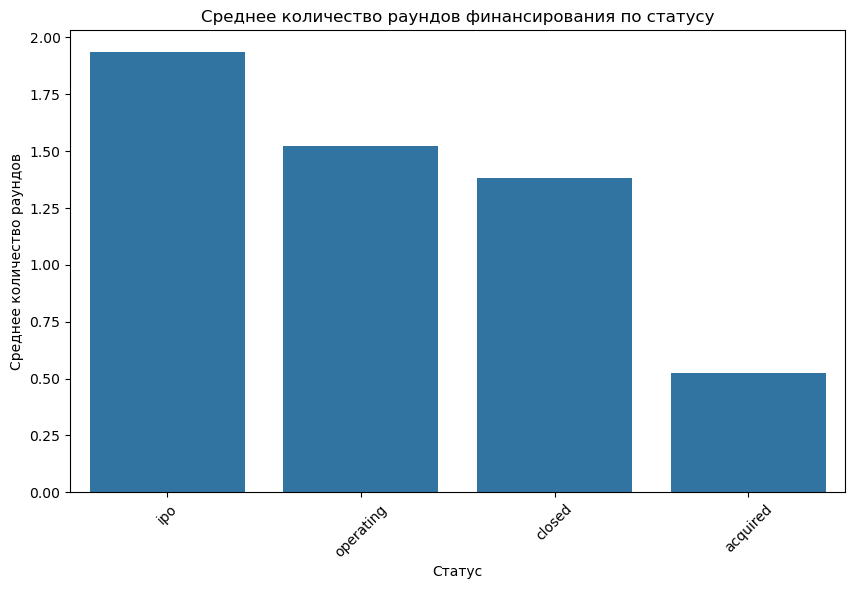

In [34]:
# убираем пропуски
rounds_data = researched_companies.dropna(subset=['funding_rounds', 'status'])

# считаем среднее и количество компаний
funding_by_status = (
    rounds_data
    .groupby('status')['funding_rounds']
    .agg(['mean', 'count'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

print(funding_by_status)

# график
plt.figure(figsize=(10,6))
sns.barplot(x='status', y='mean', data=funding_by_status)

plt.xlabel('Статус')
plt.ylabel('Среднее количество раундов')
plt.title('Среднее количество раундов финансирования по статусу')
plt.xticks(rotation=45)

plt.show()

Стартапы со статусом IPO и работающие компании обычно проходят больше раундов финансирования, около одного с половиной и почти двух в среднем. Компании, которые были проданы или закрыты, проходят меньше раундов.

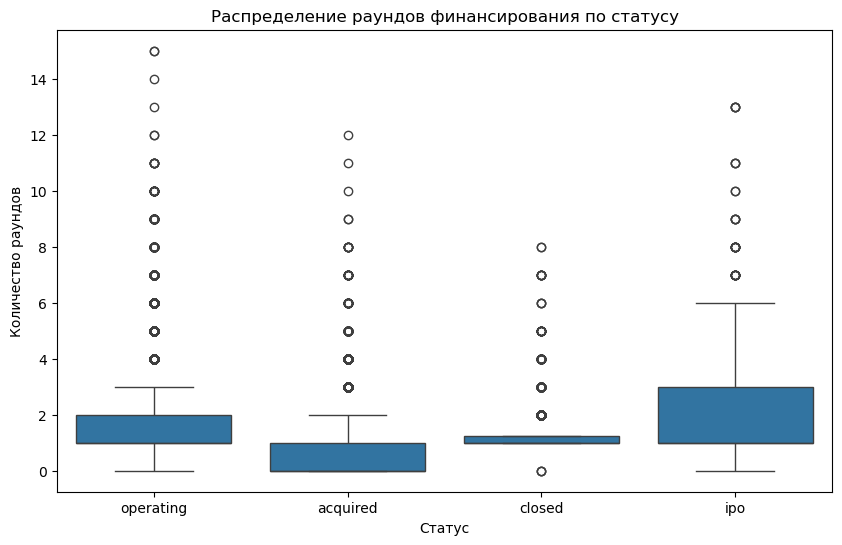

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(x='status', y='funding_rounds', data=rounds_data)
plt.xlabel('Статус')
plt.ylabel('Количество раундов')
plt.title('Распределение раундов финансирования по статусу')
plt.show()

По распределению видно, что у всех статусов медианное количество раундов находится примерно 1-2.
У acquired и closed компаний значения более сжаты, большинство из них привлекают ограниченное число раундов.
В целом распределение подтверждает, что успешные и развивающиеся компании чаще проходят больше этапов финансирования.

## Итоговый вывод и рекомендации



## Итоговые выводы и рекомендации

В рамках проекта я привёл данные из разных таблиц к единому виду, что позволило корректно объединять их и анализировать компании.

При анализе данных по сотрудникам стало видно, что информация об образовании заполнена неравномерно.
В небольших компаниях такие данные часто отсутствуют, тогда как в более крупных компаниях информация заполнена заметно лучше.

Дополнительная таблица degrees не дала существенного прироста качества данных — информация в ней также заполнена не полностью, поэтому её использование ограничено.

Анализ финансирования показал, что распределение сильно смещено: большинство компаний получают относительно небольшие суммы, а крупные инвестиции встречаются редко. Среднее значение в таких условиях искажается, поэтому для оценки типичного уровня лучше ориентироваться на медиану.

Отдельно рассмотрел сделки, где компании продавались за 0 или 1 доллар. Такие случаи встречаются даже при наличии финансирования, но это скорее исключения. Основная масса сделок находится в более высоком ценовом диапазоне.

По категориям стартапов видно, что наиболее дорогие сделки сосредоточены в сегментах вроде nanotech, manufacturing и real_estate. При этом внутри этих категорий наблюдается большой разброс цен, что говорит о высоком уровне риска.

Выяснилось, что количество раундов финансирования связано со статусом компании. Более зрелые компании (IPO и operating) в среднем проходят больше раундов, тогда как закрытые и проданные компании меньше. Это подтверждает, что привлечение инвестиций связано с развитием бизнеса, но не гарантирует успех.

### Рекомендации

При анализе стартапов стоит:
- ориентироваться на медианные значения, а не на средние, чтобы избежать влияния выбросов;
- учитывать неполноту данных по сотрудникам, особенно в небольших компаниях;
- обращать внимание на категории с высоким разбросом цен — они могут давать высокий потенциал, но связаны с рисками;
- использовать количество раундов как один из индикаторов зрелости компании, но не как единственный критерий оценки.

В целом данные позволяют выявить общие закономерности на рынке стартапов и могут быть полезны для первичной оценки инвестиционной привлекательности компаний.